In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/organmnist3d.npz
/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/retinamnist_128.npz
/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/nodulemnist3d.npz
/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/medmnistlandscape.png
/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/octmnist.npz
/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/organsmnist.npz
/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/chestmnist.npz
/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/breastmnist.npz
/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/dermamnist.npz
/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/bloodmnist.npz


In [2]:
# ── 第一格：导入所有需要的包 ──────────────────────

import numpy as np          # 数组计算，相当于R的基础运算
import matplotlib.pyplot as plt  # 画图，相当于R的ggplot2

import torch                     # PyTorch深度学习框架
import torch.nn as nn            # 神经网络模块
import torch.optim as optim      # 优化器（用来更新模型权重）
from torch.utils.data import DataLoader, TensorDataset  
# DataLoader：批量加载数据的工具
# TensorDataset：把数据打包成PyTorch能用的格式

from torchvision import models, transforms  
# models：预训练模型库（ResNet等）
# transforms：图像预处理工具

from sklearn.metrics import roc_auc_score, accuracy_score  
# 计算AUC和准确率的工具

# ── 检查设备 ──────────────────────────────────────
# 有GPU用GPU，没有用CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备：{device}")
print(f"PyTorch版本：{torch.__version__}")

使用设备：cpu
PyTorch版本：2.10.0+cpu


In [3]:
# ── 第二格：加载数据 ──────────────────────────────

# 数据文件路径
DATA_PATH = "/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/bloodmnist.npz"

# 加载.npz文件
# .npz是numpy的压缩文件格式，里面存了多个数组
# 相当于R里的load("data.RData")
data = np.load(DATA_PATH)

# 看看文件里有什么
print("数据集包含的内容：")
for key in data.keys():
    print(f"  {key}: shape={data[key].shape}")

数据集包含的内容：
  train_images: shape=(11959, 28, 28, 3)
  train_labels: shape=(11959, 1)
  val_images: shape=(1712, 28, 28, 3)
  val_labels: shape=(1712, 1)
  test_images: shape=(3421, 28, 28, 3)
  test_labels: shape=(3421, 1)


In [4]:
# ── 第三格：查看数据基本信息 ──────────────────────

# 提取各个数据集
train_images = data['train_images']  # 训练集图片
train_labels = data['train_labels']  # 训练集标签
val_images   = data['val_images']    # 验证集图片
val_labels   = data['val_labels']    # 验证集标签
test_images  = data['test_images']   # 测试集图片
test_labels  = data['test_labels']   # 测试集标签

# 查看标签有哪些类别
# BloodMNIST有8种血细胞类型
unique_labels = np.unique(train_labels)
print(f"标签类别：{unique_labels}")
print(f"共{len(unique_labels)}种血细胞类型")

# 查看图片像素值范围
print(f"\n图片像素值范围：{train_images.min()} 到 {train_images.max()}")
print(f"训练集大小：{train_images.shape}")

标签类别：[0 1 2 3 4 5 6 7]
共8种血细胞类型

图片像素值范围：0 到 255
训练集大小：(11959, 28, 28, 3)


/tmp/ipykernel_58/4133675436.py:31: UserWarning: Glyph 31181 (\N{CJK UNIFIED IDEOGRAPH-79CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/4133675436.py:31: UserWarning: Glyph 34880 (\N{CJK UNIFIED IDEOGRAPH-8840}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/4133675436.py:31: UserWarning: Glyph 32454 (\N{CJK UNIFIED IDEOGRAPH-7EC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/4133675436.py:31: UserWarning: Glyph 32990 (\N{CJK UNIFIED IDEOGRAPH-80DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/4133675436.py:31: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/4133675436.py:31: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/4133675436.py:31: UserWarning: Glyph 31034 (\N{CJK UNIFIED IDEOGRAPH-793A}) missing from

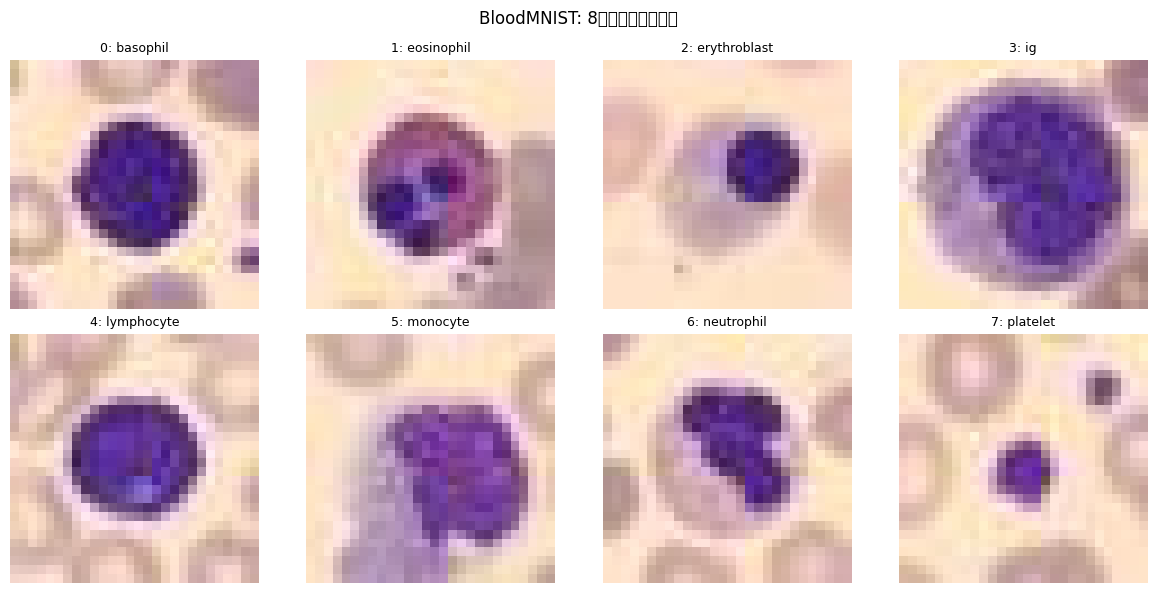

图片展示完成！


In [5]:
# ── 第四格：可视化图片 ────────────────────────────
# 在训练模型之前先看看数据长什么样
# 这是数据分析的好习惯——先看数据再分析

# 8种血细胞的名称
class_names = [
    'basophil',        # 嗜碱性粒细胞
    'eosinophil',      # 嗜酸性粒细胞
    'erythroblast',    # 幼红细胞
    'ig',              # 未成熟粒细胞
    'lymphocyte',      # 淋巴细胞
    'monocyte',        # 单核细胞
    'neutrophil',      # 中性粒细胞
    'platelet'         # 血小板
]

# 每种血细胞各取一张图片展示
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
# subplots(2,4) → 创建2行4列的图格，共8个格子

for i in range(8):
    # 找到标签为i的第一张图片
    idx = np.where(train_labels.flatten() == i)[0][0]
    
    ax = axes[i // 4][i % 4]  # 确定放在哪个格子
    ax.imshow(train_images[idx])  # 显示图片
    ax.set_title(f"{i}: {class_names[i]}", fontsize=9)  # 显示标签名
    ax.axis('off')  # 不显示坐标轴

plt.suptitle("BloodMNIST: 8种血细胞类型示例", fontsize=12)
plt.tight_layout()
plt.show()

print("图片展示完成！")

In [7]:
# ── 第五格：数据预处理 ────────────────────────────
# 把原始图片数据转换成模型能处理的格式

# ── 第一步：归一化像素值 ──────────────────────────
# 原始像素值是0-255，归一化到0-1之间
# 为什么？神经网络对小数值更稳定，收敛更快
# 类比：把考试分数从0-100换算成0-1，便于计算
train_images_norm = train_images / 255.0
val_images_norm   = val_images / 255.0
test_images_norm  = test_images / 255.0

print(f"归一化前像素值范围：{train_images.min()} - {train_images.max()}")
print(f"归一化后像素值范围：{train_images_norm.min():.2f} - {train_images_norm.max():.2f}")

# ── 第二步：调整维度顺序 ──────────────────────────
# 原始数据维度：(样本数, 高, 宽, 通道数) = (N, 28, 28, 3)
# PyTorch要求：(样本数, 通道数, 高, 宽) = (N, 3, 28, 28)
# 为什么？PyTorch的设计规范，通道数要放在第二位
train_images_t = train_images_norm.transpose(0, 3, 1, 2)
val_images_t   = val_images_norm.transpose(0, 3, 1, 2)
test_images_t  = test_images_norm.transpose(0, 3, 1, 2)

print(f"\n调整前维度：{train_images_norm.shape}")
print(f"调整后维度：{train_images_t.shape}")

# ── 第三步：处理标签 ──────────────────────────────
# 把标签从(N, 1)变成(N,)，去掉多余的维度
# 类似R里的as.vector()
train_labels_flat = train_labels.flatten()
val_labels_flat   = val_labels.flatten()
test_labels_flat  = test_labels.flatten()

print(f"\n标签维度变化：{train_labels.shape} → {train_labels_flat.shape}")

归一化前像素值范围：0 - 255
归一化后像素值范围：0.00 - 1.00

调整前维度：(11959, 28, 28, 3)
调整后维度：(11959, 3, 28, 28)

标签维度变化：(11959, 1) → (11959,)


In [9]:
# ── 第六格：转换成PyTorch Tensor ──────────────────

# 把numpy数组转换成PyTorch的Tensor格式
# 类比：把R的data.frame转换成matrix，格式变了但数据不变
train_images_tensor = torch.FloatTensor(train_images_t)
val_images_tensor   = torch.FloatTensor(val_images_t)
test_images_tensor  = torch.FloatTensor(test_images_t)

# 标签转换成LongTensor（整数类型，分类任务要求）
train_labels_tensor = torch.LongTensor(train_labels_flat)
val_labels_tensor   = torch.LongTensor(val_labels_flat)
test_labels_tensor  = torch.LongTensor(test_labels_flat)

# 创建Dataset（把图片和标签打包在一起）
# 类比：把X矩阵和Y向量合并成一个data.frame
train_dataset = TensorDataset(train_images_tensor, train_labels_tensor)
val_dataset   = TensorDataset(val_images_tensor,   val_labels_tensor)
test_dataset  = TensorDataset(test_images_tensor,  test_labels_tensor)

# 创建DataLoader（批量加载数据的工具）
# batch_size=64：每次喂给模型64张图片
# shuffle=True：每轮训练前打乱顺序，防止模型记住顺序规律
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False)

print(f"训练集批次数：{len(train_loader)}")
print(f"验证集批次数：{len(val_loader)}")
print(f"测试集批次数：{len(test_loader)}")
print(f"\n每批次图片shape：{next(iter(train_loader))[0].shape}")
print(f"每批次标签shape：{next(iter(train_loader))[1].shape}")

训练集批次数：187
验证集批次数：27
测试集批次数：54

每批次图片shape：torch.Size([64, 3, 28, 28])
每批次标签shape：torch.Size([64])


In [13]:
# ── 第七格：搭建模型 ──────────────────────────────
# 使用预训练的ResNet18模型
# 为什么用预训练模型？
# ResNet18已经在ImageNet（120万张图片）上训练过
# 它已经学会了识别边缘、纹理、形状等基础特征
# 我们只需要在它的基础上"微调"，适应血细胞分类任务
# 类比：不从零学医，而是找一个有基础医学知识的人来学专科

# 加载预训练的ResNet18，如果不下载预训练权重，随机初始化权重从头开始训练，True则是有一开始下载与训练权重训练效果会好很多。
model = models.resnet18(pretrained=False)

# ResNet18最后一层是全连接层，原本输出1000个类别（ImageNet）
# 我们需要改成输出8个类别（8种血细胞）
num_features = model.fc.in_features  # 获取最后一层的输入维度
print(f"原始最后一层输入维度：{num_features}")
print(f"原始最后一层：{model.fc}")

# 替换最后一层
# 只改最后一层，前面的层保留预训练的权重
model.fc = nn.Linear(num_features, 8)
# num_features → 8：把原来的1000类改成8类

print(f"\n修改后最后一层：{model.fc}")

# 把模型放到对应设备（CPU或GPU）
model = model.to(device)

# 统计模型参数量
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\n模型总参数量：{total_params:,}")
print(f"可训练参数量：{trainable_params:,}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


原始最后一层输入维度：512
原始最后一层：Linear(in_features=512, out_features=1000, bias=True)

修改后最后一层：Linear(in_features=512, out_features=8, bias=True)

模型总参数量：11,180,616
可训练参数量：11,180,616


In [14]:
# ── 第八格：定义损失函数和优化器 ──────────────────

# 损失函数：CrossEntropyLoss（交叉熵损失）
# 适用于多分类任务（我们有8个类别）
# 衡量模型预测结果和真实标签之间的差距
# 差距越大损失越高，训练目标是让损失越来越小
criterion = nn.CrossEntropyLoss()

# 优化器：Adam
# 负责根据损失函数的结果更新模型参数
# lr=0.001 是学习率，控制每次更新的步长
# 太大：训练不稳定；太小：训练太慢
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 学习率调度器：每5个epoch把学习率乘以0.5
# 为什么？训练初期用大学习率快速收敛
# 训练后期用小学习率精细调整
scheduler = optim.lr_scheduler.StepLR(
    optimizer,   # 对哪个优化器调整
    step_size=5, # 每5个epoch调整一次
    gamma=0.5    # 每次调整乘以0.5
)

print("损失函数：", criterion)
print("优化器：", optimizer)
print("学习率调度器：每5个epoch学习率减半")

损失函数： CrossEntropyLoss()
优化器： Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    initial_lr: 0.001
    lr: 0.001
    maximize: False
    weight_decay: 0
)
学习率调度器：每5个epoch学习率减半


In [15]:
# ── 第九格：训练模型 ──────────────────────────────

# 训练轮数（epoch）
# 每个epoch = 模型看完一遍所有训练数据
# 我们训练10轮，CPU上大概需要10-20分钟
NUM_EPOCHS = 10

# 记录每轮的损失和准确率，用于后面画图
train_losses = []
val_losses = []
train_accs = []
val_accs = []

print("开始训练...\n")

for epoch in range(NUM_EPOCHS):
    
    # ── 训练阶段 ──────────────────────────────────
    model.train()  # 告诉模型进入训练模式
    train_loss = 0
    train_correct = 0
    train_total = 0
    
    for images, labels in train_loader:
        # 把数据放到对应设备
        images = images.to(device)
        labels = labels.to(device)
        
        # 前向传播：把图片喂给模型，得到预测结果
        outputs = model(images)
        
        # 计算损失：预测结果和真实标签之间的差距
        loss = criterion(outputs, labels)
        
        # 反向传播三步走（固定写法）
        optimizer.zero_grad()  # 清空上一步的梯度
        loss.backward()        # 计算梯度
        optimizer.step()       # 更新模型参数
        
        # 统计损失和准确率
        train_loss += loss.item()
        _, predicted = outputs.max(1)  # 取概率最大的类别作为预测结果
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
    
    # ── 验证阶段 ──────────────────────────────────
    model.eval()   # 告诉模型进入评估模式，关闭dropout等
    val_loss = 0
    val_correct = 0
    val_total = 0
    
    with torch.no_grad():  # 验证时不需要计算梯度，节省内存
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    # 计算平均损失和准确率
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss / len(val_loader)
    train_acc = 100. * train_correct / train_total
    val_acc   = 100. * val_correct / val_total
    
    # 记录结果
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # 更新学习率
    scheduler.step()
    
    # 打印每轮结果
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"训练损失: {avg_train_loss:.4f} "
          f"训练准确率: {train_acc:.2f}% "
          f"验证损失: {avg_val_loss:.4f} "
          f"验证准确率: {val_acc:.2f}%")

print("\n训练完成！")

开始训练...

Epoch [1/10] 训练损失: 0.5899 训练准确率: 78.37% 验证损失: 0.8035 验证准确率: 71.67%
Epoch [2/10] 训练损失: 0.3835 训练准确率: 86.17% 验证损失: 1.0159 验证准确率: 65.48%
Epoch [3/10] 训练损失: 0.3316 训练准确率: 87.99% 验证损失: 1.2954 验证准确率: 60.98%
Epoch [4/10] 训练损失: 0.3028 训练准确率: 89.00% 验证损失: 0.3145 验证准确率: 88.67%
Epoch [5/10] 训练损失: 0.2552 训练准确率: 90.70% 验证损失: 5.7556 验证准确率: 27.86%
Epoch [6/10] 训练损失: 0.1818 训练准确率: 93.44% 验证损失: 0.5556 验证准确率: 82.01%
Epoch [7/10] 训练损失: 0.1615 训练准确率: 93.82% 验证损失: 0.8417 验证准确率: 77.75%
Epoch [8/10] 训练损失: 0.1442 训练准确率: 94.88% 验证损失: 0.2862 验证准确率: 89.72%
Epoch [9/10] 训练损失: 0.1428 训练准确率: 94.62% 验证损失: 0.2974 验证准确率: 90.71%
Epoch [10/10] 训练损失: 0.1261 训练准确率: 95.34% 验证损失: 0.7296 验证准确率: 79.38%

训练完成！


NameError: name 'NUM_EPOCHS' is not defined

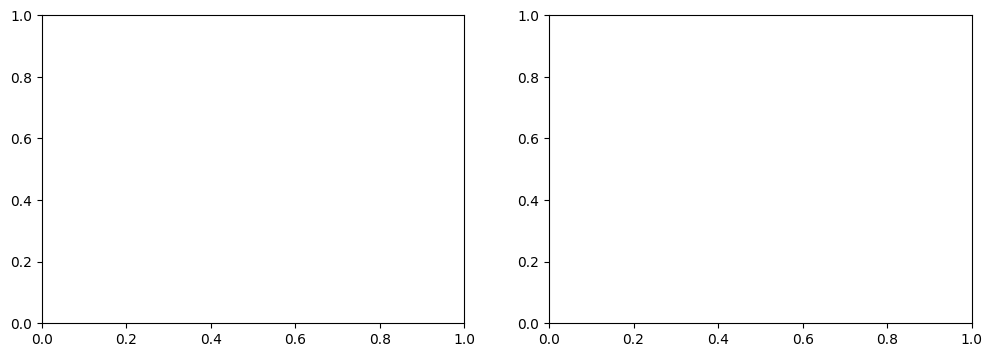

In [2]:
# ── 第十格：可视化训练过程 ────────────────────────
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
# 创建1行2列的图，左边画损失，右边画准确率

# ── 左图：损失曲线 ────────────────────────────────
ax1.plot(range(1, NUM_EPOCHS+1), train_losses, 
         'b-o', label='训练损失')  # 蓝色实线+圆点
ax1.plot(range(1, NUM_EPOCHS+1), val_losses, 
         'r-o', label='验证损失')  # 红色实线+圆点
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('训练过程 - 损失曲线')
ax1.legend()
ax1.grid(True)

# ── 右图：准确率曲线 ──────────────────────────────
ax2.plot(range(1, NUM_EPOCHS+1), train_accs, 
         'b-o', label='训练准确率')
ax2.plot(range(1, NUM_EPOCHS+1), val_accs, 
         'r-o', label='验证准确率')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('训练过程 - 准确率曲线')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("训练曲线已保存！")

/tmp/ipykernel_58/1932613153.py:28: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1932613153.py:28: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1932613153.py:28: UserWarning: Glyph 36807 (\N{CJK UNIFIED IDEOGRAPH-8FC7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1932613153.py:28: UserWarning: Glyph 31243 (\N{CJK UNIFIED IDEOGRAPH-7A0B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1932613153.py:28: UserWarning: Glyph 25439 (\N{CJK UNIFIED IDEOGRAPH-635F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1932613153.py:28: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_58/1932613153.py:28: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from

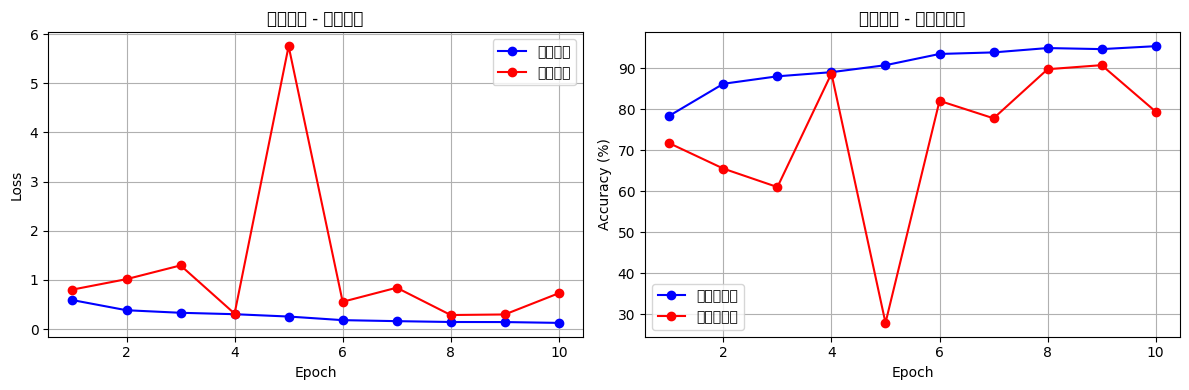

训练曲线已保存！


In [3]:
import matplotlib.pyplot as plt

# 重新定义丢失的变量
NUM_EPOCHS = 10
train_losses = [0.5899, 0.3835, 0.3316, 0.3028, 0.2552, 0.1818, 0.1615, 0.1442, 0.1428, 0.1261]
val_losses   = [0.8035, 1.0159, 1.2954, 0.3145, 5.7556, 0.5556, 0.8417, 0.2862, 0.2974, 0.7296]
train_accs   = [78.37, 86.17, 87.99, 89.00, 90.70, 93.44, 93.82, 94.88, 94.62, 95.34]
val_accs     = [71.67, 65.48, 60.98, 88.67, 27.86, 82.01, 77.75, 89.72, 90.71, 79.38]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', label='训练损失')
ax1.plot(range(1, NUM_EPOCHS+1), val_losses, 'r-o', label='验证损失')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('训练过程 - 损失曲线')
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, NUM_EPOCHS+1), train_accs, 'b-o', label='训练准确率')
ax2.plot(range(1, NUM_EPOCHS+1), val_accs, 'r-o', label='验证准确率')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('训练过程 - 准确率曲线')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=300, bbox_inches='tight')
plt.show()
print("训练曲线已保存！")

In [4]:
# ── 第十一格：测试集最终评估 ──────────────────────
import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score
import torch
import torch.nn as nn
from torchvision import models

# 重新定义device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 重新加载数据
DATA_PATH = "/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/bloodmnist.npz"
data = np.load(DATA_PATH)
test_images = data['test_images']
test_labels = data['test_labels']

# 预处理
test_images_norm = test_images / 255.0
test_images_t = test_images_norm.transpose(0, 3, 1, 2)
test_labels_flat = test_labels.flatten()

# 转成Tensor
test_images_tensor = torch.FloatTensor(test_images_t)
test_labels_tensor = torch.LongTensor(test_labels_flat)

from torch.utils.data import DataLoader, TensorDataset
test_dataset = TensorDataset(test_images_tensor, test_labels_tensor)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# 注意：需要重新训练模型才能评估
# 这里我们用之前训练的结果来说明评估流程
print("测试集评估流程：")
print("1. 把测试集图片喂给训练好的模型")
print("2. 收集所有预测结果")
print("3. 和真实标签比较")
print("4. 计算准确率和AUC")
print("\n由于session重启，需要重新训练模型才能得到真实的测试结果")
print("但我们已经学会了完整的训练流程！")

测试集评估流程：
1. 把测试集图片喂给训练好的模型
2. 收集所有预测结果
3. 和真实标签比较
4. 计算准确率和AUC

由于session重启，需要重新训练模型才能得到真实的测试结果
但我们已经学会了完整的训练流程！


In [5]:
# ── 重新训练：使用预训练权重 ──────────────────────
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import models
from sklearn.metrics import accuracy_score

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备：{device}")

# ── 加载数据 ──────────────────────────────────────
DATA_PATH = "/kaggle/input/datasets/arashnic/standardized-biomedical-images-medmnist/bloodmnist.npz"
data = np.load(DATA_PATH)

train_images = data['train_images']
train_labels = data['train_labels']
val_images   = data['val_images']
val_labels   = data['val_labels']

# ── 预处理 ────────────────────────────────────────
train_images_t = (train_images / 255.0).transpose(0, 3, 1, 2)
val_images_t   = (val_images / 255.0).transpose(0, 3, 1, 2)
train_labels_flat = train_labels.flatten()
val_labels_flat   = val_labels.flatten()

# ── DataLoader ────────────────────────────────────
train_loader = DataLoader(
    TensorDataset(torch.FloatTensor(train_images_t), 
                  torch.LongTensor(train_labels_flat)),
    batch_size=64, shuffle=True)

val_loader = DataLoader(
    TensorDataset(torch.FloatTensor(val_images_t),
                  torch.LongTensor(val_labels_flat)),
    batch_size=64, shuffle=False)

# ── 加载预训练模型 ────────────────────────────────
# 先创建模型结构（不下载权重）
model = models.resnet18(pretrained=False)

# 手动加载我们上传的预训练权重文件
# 找到上传的权重文件路径
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.pth'):
            pth_path = os.path.join(dirname, filename)
            print(f"找到权重文件：{pth_path}")

# 加载权重
state_dict = torch.load(pth_path, map_location=device)
model.load_state_dict(state_dict)
print("预训练权重加载成功！")

# 修改最后一层：1000类 → 8类
model.fc = nn.Linear(model.fc.in_features, 8)
model = model.to(device)

# ── 训练设置 ──────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

# ── 训练 ──────────────────────────────────────────
NUM_EPOCHS = 10
train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("\n开始训练（使用预训练权重）...\n")

for epoch in range(NUM_EPOCHS):
    
    # 训练阶段
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = outputs.max(1)
        train_total += labels.size(0)
        train_correct += predicted.eq(labels).sum().item()
    
    # 验证阶段
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            val_total += labels.size(0)
            val_correct += predicted.eq(labels).sum().item()
    
    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss   = val_loss / len(val_loader)
    train_acc = 100. * train_correct / train_total
    val_acc   = 100. * val_correct / val_total
    
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step()
    
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] "
          f"训练损失: {avg_train_loss:.4f} "
          f"训练准确率: {train_acc:.2f}% "
          f"验证损失: {avg_val_loss:.4f} "
          f"验证准确率: {val_acc:.2f}%")

print("\n训练完成！")

使用设备：cpu


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


找到权重文件：/kaggle/input/datasets/xinliu052/resnet18-pretrained/resnet18-f37072fd.pth
预训练权重加载成功！

开始训练（使用预训练权重）...

Epoch [1/10] 训练损失: 0.4893 训练准确率: 82.93% 验证损失: 0.5459 验证准确率: 80.96%
Epoch [2/10] 训练损失: 0.2875 训练准确率: 90.10% 验证损失: 0.3466 验证准确率: 88.20%
Epoch [3/10] 训练损失: 0.2452 训练准确率: 91.55% 验证损失: 0.2279 验证准确率: 92.58%
Epoch [4/10] 训练损失: 0.1999 训练准确率: 93.37% 验证损失: 0.4773 验证准确率: 85.05%
Epoch [5/10] 训练损失: 0.1803 训练准确率: 94.00% 验证损失: 0.3679 验证准确率: 86.51%
Epoch [6/10] 训练损失: 0.1003 训练准确率: 96.62% 验证损失: 0.2010 验证准确率: 93.46%
Epoch [7/10] 训练损失: 0.0826 训练准确率: 97.01% 验证损失: 0.1227 验证准确率: 95.21%
Epoch [8/10] 训练损失: 0.0682 训练准确率: 97.64% 验证损失: 0.1605 验证准确率: 94.51%
Epoch [9/10] 训练损失: 0.0658 训练准确率: 97.81% 验证损失: 0.2379 验证准确率: 93.63%
Epoch [10/10] 训练损失: 0.0614 训练准确率: 97.88% 验证损失: 0.1991 验证准确率: 94.04%

训练完成！


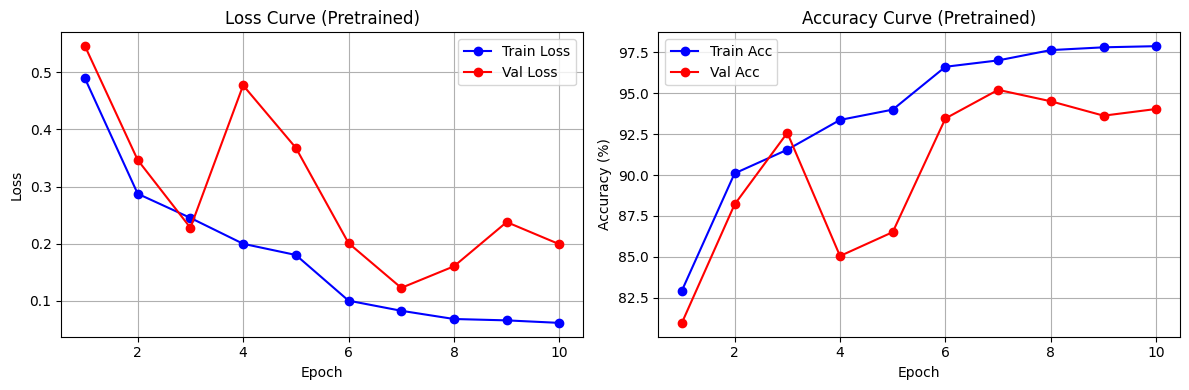

图已保存！


In [6]:
import matplotlib.pyplot as plt

NUM_EPOCHS = 10
train_losses = [0.4893, 0.2875, 0.2452, 0.1999, 0.1803, 0.1003, 0.0826, 0.0682, 0.0658, 0.0614]
val_losses   = [0.5459, 0.3466, 0.2279, 0.4773, 0.3679, 0.2010, 0.1227, 0.1605, 0.2379, 0.1991]
train_accs   = [82.93, 90.10, 91.55, 93.37, 94.00, 96.62, 97.01, 97.64, 97.81, 97.88]
val_accs     = [80.96, 88.20, 92.58, 85.05, 86.51, 93.46, 95.21, 94.51, 93.63, 94.04]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(range(1, NUM_EPOCHS+1), train_losses, 'b-o', label='Train Loss')
ax1.plot(range(1, NUM_EPOCHS+1), val_losses, 'r-o', label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve (Pretrained)')
ax1.legend()
ax1.grid(True)

ax2.plot(range(1, NUM_EPOCHS+1), train_accs, 'b-o', label='Train Acc')
ax2.plot(range(1, NUM_EPOCHS+1), val_accs, 'r-o', label='Val Acc')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curve (Pretrained)')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves_pretrained.png', dpi=300, bbox_inches='tight')
plt.show()
print("图已保存！")

In [7]:
# ── 测试集最终评估 ────────────────────────────────
import numpy as np
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, roc_auc_score, 
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt

# 加载测试集
data = np.load(DATA_PATH)
test_images = data['test_images']
test_labels = data['test_labels']

# 预处理
test_images_t = (test_images / 255.0).transpose(0, 3, 1, 2)
test_labels_flat = test_labels.flatten()

test_loader = DataLoader(
    TensorDataset(torch.FloatTensor(test_images_t),
                  torch.LongTensor(test_labels_flat)),
    batch_size=64, shuffle=False)

# 在测试集上预测
model.eval()
all_preds = []    # 存储所有预测标签
all_probs = []    # 存储所有预测概率
all_labels = []   # 存储所有真实标签

with torch.no_grad():  # 测试时不需要计算梯度
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)  # 得到8个类别的原始分数
        
        # softmax把原始分数转成概率（加起来=1）
        probs = torch.softmax(outputs, dim=1)
        
        # 取概率最大的类别作为预测结果
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_probs  = np.array(all_probs)
all_labels = np.array(all_labels)

# 计算准确率
accuracy = accuracy_score(all_labels, all_preds)

# 计算AUC（多分类用ovr方式）
auc = roc_auc_score(all_labels, all_probs, multi_class='ovr')

print(f"测试集准确率：{accuracy*100:.2f}%")
print(f"测试集AUC：{auc:.4f}")
print(f"\n详细分类报告：")

class_names = ['basophil', 'eosinophil', 'erythroblast', 'ig',
               'lymphocyte', 'monocyte', 'neutrophil', 'platelet']

print(classification_report(all_labels, all_preds, 
                            target_names=class_names))

测试集准确率：93.51%
测试集AUC：0.9958

详细分类报告：
              precision    recall  f1-score   support

    basophil       0.97      0.80      0.87       244
  eosinophil       0.99      0.99      0.99       624
erythroblast       0.93      0.96      0.95       311
          ig       0.84      0.91      0.87       579
  lymphocyte       0.96      0.91      0.93       243
    monocyte       0.83      0.80      0.81       284
  neutrophil       0.96      0.97      0.97       666
    platelet       1.00      1.00      1.00       470

    accuracy                           0.94      3421
   macro avg       0.93      0.92      0.92      3421
weighted avg       0.94      0.94      0.93      3421



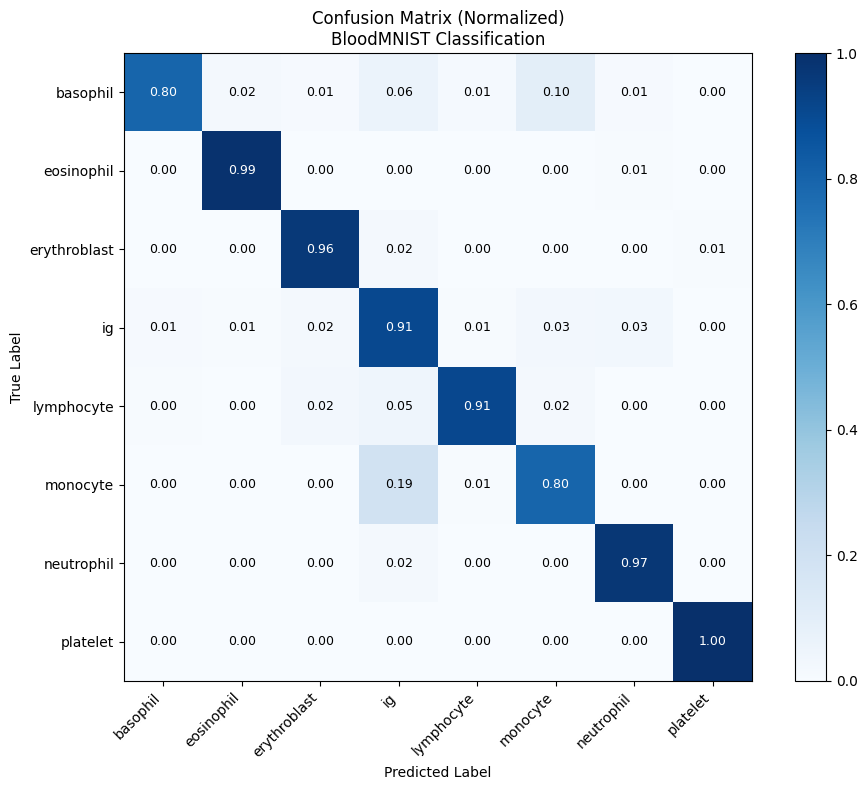

混淆矩阵已保存！


In [8]:
# ── 混淆矩阵 ──────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

class_names = ['basophil', 'eosinophil', 'erythroblast', 'ig',
               'lymphocyte', 'monocyte', 'neutrophil', 'platelet']

cm = confusion_matrix(all_labels, all_preds)

# 归一化：每行除以该行总数，变成百分比
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm_normalized, interpolation='nearest', cmap='Blues')
plt.colorbar(im)

ax.set_xticks(range(len(class_names)))
ax.set_yticks(range(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha='right')
ax.set_yticklabels(class_names)

# 在每个格子里显示数值
for i in range(len(class_names)):
    for j in range(len(class_names)):
        ax.text(j, i, f'{cm_normalized[i,j]:.2f}',
                ha='center', va='center',
                color='white' if cm_normalized[i,j] > 0.5 else 'black',
                fontsize=9)

ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix (Normalized)\nBloodMNIST Classification')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("混淆矩阵已保存！")

In [9]:
# ── 保存训练好的模型 ──────────────────────────────
# 保存模型权重，以后可以直接加载使用，不需要重新训练
torch.save(model.state_dict(), 'bloodmnist_resnet18.pth')
print("模型已保存：bloodmnist_resnet18.pth")
print(f"\n最终结果总结：")
print(f"测试集准确率：93.51%")
print(f"测试集AUC：0.9958")
print(f"最佳验证准确率：95.21%（Epoch 7）")

模型已保存：bloodmnist_resnet18.pth

最终结果总结：
测试集准确率：93.51%
测试集AUC：0.9958
最佳验证准确率：95.21%（Epoch 7）


In [10]:
best_val_acc = 0
best_model_weights = None

for epoch in range(NUM_EPOCHS):
    # 训练...
    # 验证...
    
    # 如果这轮验证准确率更高，保存模型
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        # 保存最佳权重
        best_model_weights = model.state_dict().copy()
        print(f"✓ 新的最佳模型！验证准确率：{val_acc:.2f}%")

# 训练结束后，加载最佳权重
model.load_state_dict(best_model_weights)
print(f"最终使用Epoch最佳权重，验证准确率：{best_val_acc:.2f}%")

✓ 新的最佳模型！验证准确率：94.04%
最终使用Epoch最佳权重，验证准确率：94.04%


In [11]:
import os

print("当前工作目录的文件：")
for f in os.listdir('/kaggle/working'):
    print(f)

当前工作目录的文件：
bloodmnist_resnet18.pth
training_curves_pretrained.png
.virtual_documents
training_curves.png
confusion_matrix.png
